In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simple FMCW radar example with three moving targets
# The goal is to show the main signal-processing steps:
# chirp -> beat signal -> Range FFT -> Range-Doppler map -> CFAR detections

np.random.seed(2)

# ------------------------------------------------------------
# Radar setup
# ------------------------------------------------------------

c = 3e8                  # speed of light
fc = 77e9                # carrier frequency

max_range = 200          # meters
range_resolution = 1     # meters

B = c / (2 * range_resolution)
T_chirp = 5.5 * 2 * max_range / c
slope = B / T_chirp

Nr = 1024                # samples inside one chirp
Nd = 128                 # number of chirps

t_fast = np.linspace(0, T_chirp, Nr, endpoint=False)
t_slow = np.arange(Nd) * T_chirp

# Range axis from beat frequency
range_freq = np.fft.fftfreq(Nr, d=T_chirp / Nr)[:Nr // 2]
range_axis = range_freq * c / (2 * slope)

# Velocity axis from Doppler frequency
doppler_freq = np.fft.fftshift(np.fft.fftfreq(Nd, d=T_chirp))
velocity_axis = -doppler_freq * c / (2 * fc)

# ------------------------------------------------------------
# Targets in the scene
# ------------------------------------------------------------

targets = [
    {"range": 40.3,  "velocity": 10,  "amplitude": 1.0},
    {"range": 80.7,  "velocity": -15, "amplitude": 0.8},
    {"range": 130.4, "velocity": 5,   "amplitude": 0.6},
]

# ------------------------------------------------------------
# Simulate the beat signal
# ------------------------------------------------------------

beat_data = np.zeros((Nd, Nr), dtype=complex)

for target in targets:
    R = target["range"]
    v = target["velocity"]
    A = target["amplitude"]

    tau = 2 * R / c
    fD = -2 * fc * v / c

    for chirp_idx in range(Nd):
        phase = 2 * np.pi * (
            fc * tau
            + fD * t_slow[chirp_idx]
            + slope * tau * t_fast
        )

        beat_data[chirp_idx, :] += A * np.exp(1j * phase)

# A simple transmitted chirp for visualization
tx_chirp = np.cos(2 * np.pi * 0.5 * slope * t_fast**2)

# Real part of the mixed beat signal from the first chirp
beat_signal = np.real(beat_data[0, :])

# ------------------------------------------------------------
# Range FFT
# ------------------------------------------------------------

range_fft_all_chirps = np.fft.fft(beat_data, axis=1)
range_fft_all_chirps = range_fft_all_chirps[:, :Nr // 2]

range_fft_one_chirp = np.abs(range_fft_all_chirps[0])
range_fft_one_chirp_db = 20 * np.log10(
    range_fft_one_chirp / np.max(range_fft_one_chirp) + 1e-12
)

range_fft_one_chirp_db = np.maximum(range_fft_one_chirp_db, -80)

range_fft_image_db = 20 * np.log10(
    np.abs(range_fft_all_chirps) / np.max(np.abs(range_fft_all_chirps)) + 1e-12
)

range_fft_image_db = np.maximum(range_fft_image_db, -70)

# ------------------------------------------------------------
# Range-Doppler map
# ------------------------------------------------------------

def make_range_doppler_map(data, use_window=False):
    data = data.copy()

    if use_window:
        range_window = np.hanning(Nr)
        doppler_window = np.hanning(Nd)

        data = data * range_window
        data = (data.T * doppler_window).T

    range_fft = np.fft.fft(data, axis=1)
    range_fft = range_fft[:, :Nr // 2]

    doppler_fft = np.fft.fft(range_fft, axis=0)
    doppler_fft = np.fft.fftshift(doppler_fft, axes=0)

    rdm_db = 20 * np.log10(np.abs(doppler_fft) + 1e-12)
    rdm_db = rdm_db - np.max(rdm_db)
    rdm_db = np.maximum(rdm_db, -80)

    return doppler_fft, rdm_db


rdm_raw, rdm_raw_db = make_range_doppler_map(
    beat_data,
    use_window=False
)

rdm_windowed, rdm_windowed_db = make_range_doppler_map(
    beat_data,
    use_window=True
)

# ------------------------------------------------------------
# Simple CA-CFAR
# ------------------------------------------------------------

def ca_cfar_2d(power_map, guard_cells=2, training_cells=10, threshold_scale=12):
    rows, cols = power_map.shape
    detections = np.zeros_like(power_map, dtype=bool)

    margin = guard_cells + training_cells

    for row in range(margin, rows - margin):
        for col in range(margin, cols - margin):

            full_area = power_map[
                row - margin:row + margin + 1,
                col - margin:col + margin + 1
            ]

            guard_area = power_map[
                row - guard_cells:row + guard_cells + 1,
                col - guard_cells:col + guard_cells + 1
            ]

            noise_sum = np.sum(full_area) - np.sum(guard_area)
            noise_cells = full_area.size - guard_area.size
            noise_level = noise_sum / noise_cells

            threshold = threshold_scale * noise_level

            if power_map[row, col] > threshold:
                detections[row, col] = True

    return detections


def keep_local_peaks(power_map, detections, window_size=7):
    rows, cols = power_map.shape
    peaks = np.zeros_like(detections)

    half_window = window_size // 2

    for row in range(half_window, rows - half_window):
        for col in range(half_window, cols - half_window):

            if detections[row, col]:
                local_area = power_map[
                    row - half_window:row + half_window + 1,
                    col - half_window:col + half_window + 1
                ]

                if power_map[row, col] == np.max(local_area):
                    peaks[row, col] = True

    return peaks


rdm_power = np.abs(rdm_windowed) ** 2

cfar_detections = ca_cfar_2d(
    rdm_power,
    guard_cells=2,
    training_cells=10,
    threshold_scale=12
)

# Keep only the useful detection region
cfar_detections &= rdm_windowed_db > -25
cfar_detections[:, range_axis > 155] = False

final_detections = keep_local_peaks(
    rdm_power,
    cfar_detections,
    window_size=7
)

# Read out the final range and velocity values
det_rows, det_cols = np.where(final_detections)

detected_targets = []

for row, col in zip(det_rows, det_cols):
    detected_targets.append({
        "range": range_axis[col],
        "velocity": velocity_axis[row],
        "magnitude_db": rdm_windowed_db[row, col]
    })

detected_targets = sorted(
    detected_targets,
    key=lambda x: x["magnitude_db"],
    reverse=True
)

print("Detected targets:")
for i, target in enumerate(detected_targets[:3], start=1):
    print(
        f"T{i}: Range = {target['range']:.1f} m, "
        f"Velocity = {target['velocity']:.1f} m/s, "
        f"Magnitude = {target['magnitude_db']:.1f} dB"
    )


Detected targets:
T1: Range = 40.0 m, Velocity = 10.4 m/s, Magnitude = 0.0 dB
T2: Range = 81.0 m, Velocity = -14.5 m/s, Magnitude = -2.0 dB
T3: Range = 130.0 m, Velocity = 4.2 m/s, Magnitude = -5.6 dB


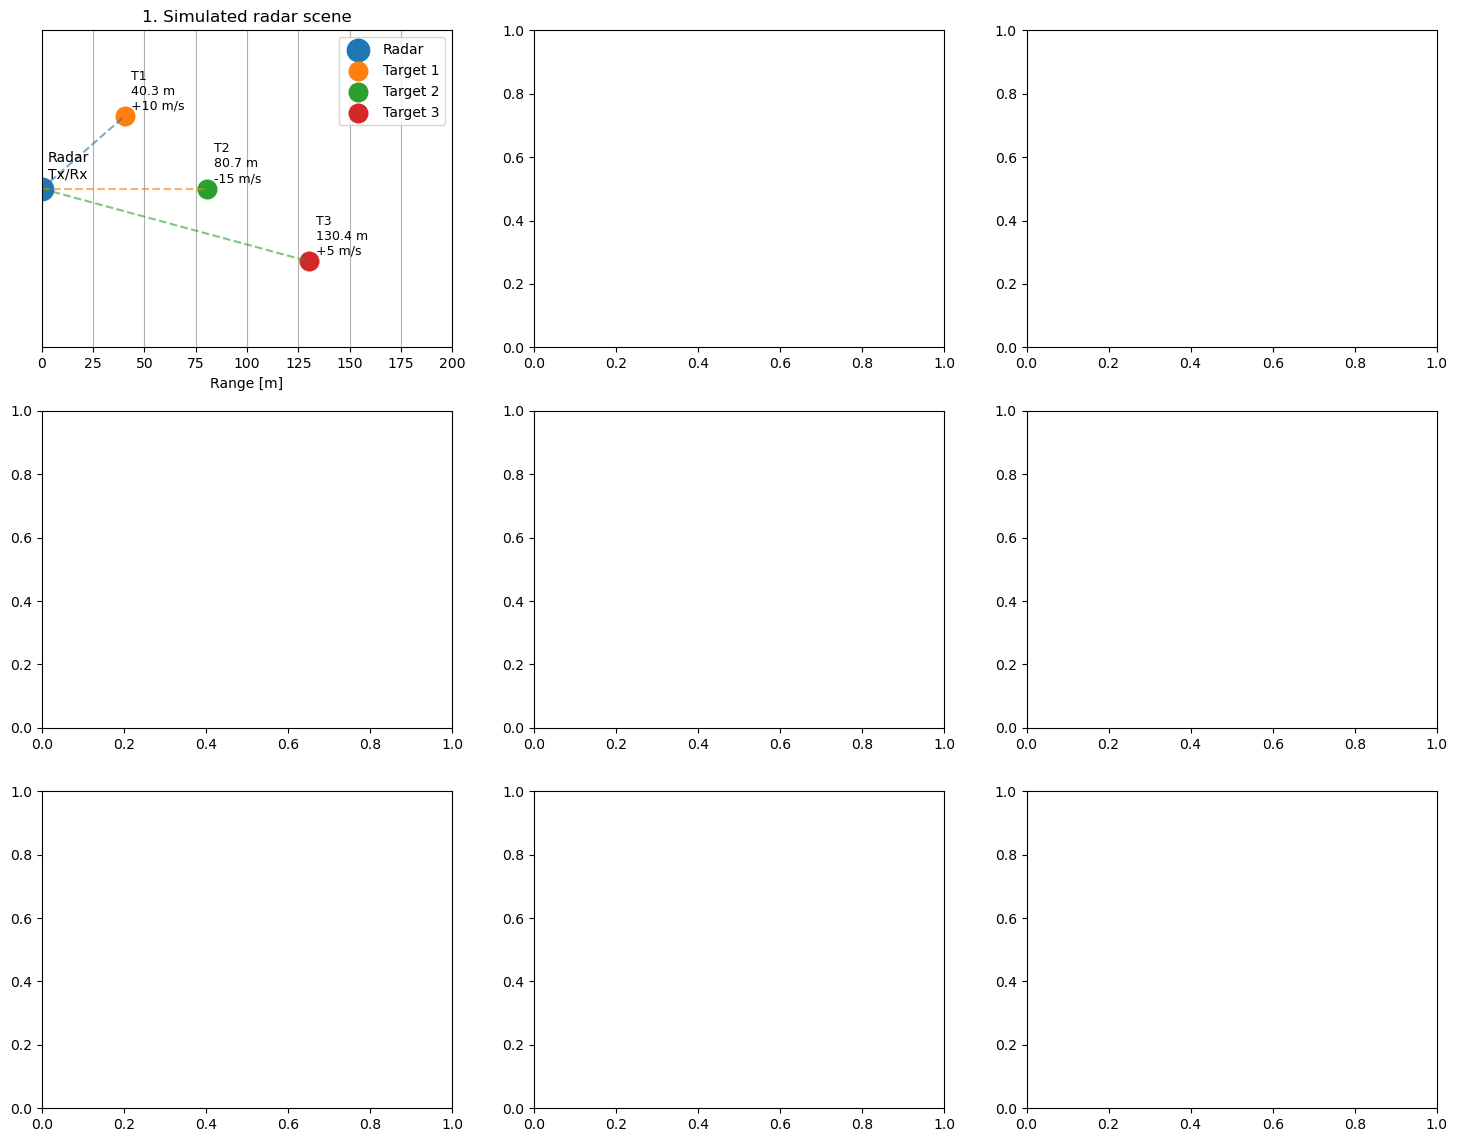

In [12]:

# ------------------------------------------------------------
# Plot everything
# ------------------------------------------------------------

fig, axs = plt.subplots(3, 3, figsize=(18, 14))
axs = axs.ravel()

# ------------------------------------------------------------
# 1. Simulated radar scene
# ------------------------------------------------------------

ax = axs[0]

ax.scatter(0, 0, s=260, label="Radar")
ax.text(3, 0.08, "Radar\nTx/Rx", fontsize=10)

y_positions = [0.55, 0.0, -0.55]

for idx, target in enumerate(targets):
    R = target["range"]
    v = target["velocity"]
    y = y_positions[idx]

    ax.scatter(R, y, s=180, label=f"Target {idx + 1}")
    ax.plot([0, R], [0, y], "--", alpha=0.6)

    ax.text(
        R + 3,
        y + 0.05,
        f"T{idx + 1}\n{R:.1f} m\n{v:+.0f} m/s",
        fontsize=9
    )

ax.set_title("1. Simulated radar scene")
ax.set_xlabel("Range [m]")
ax.set_xlim(0, max_range)
ax.set_ylim(-1.2, 1.2)
ax.set_yticks([])
ax.grid(True)
ax.legend(loc="upper right")


Detected targets:
T1: Range = 40.0 m, Velocity = 10.4 m/s
T2: Range = 81.0 m, Velocity = -14.5 m/s
T3: Range = 130.0 m, Velocity = 4.2 m/s


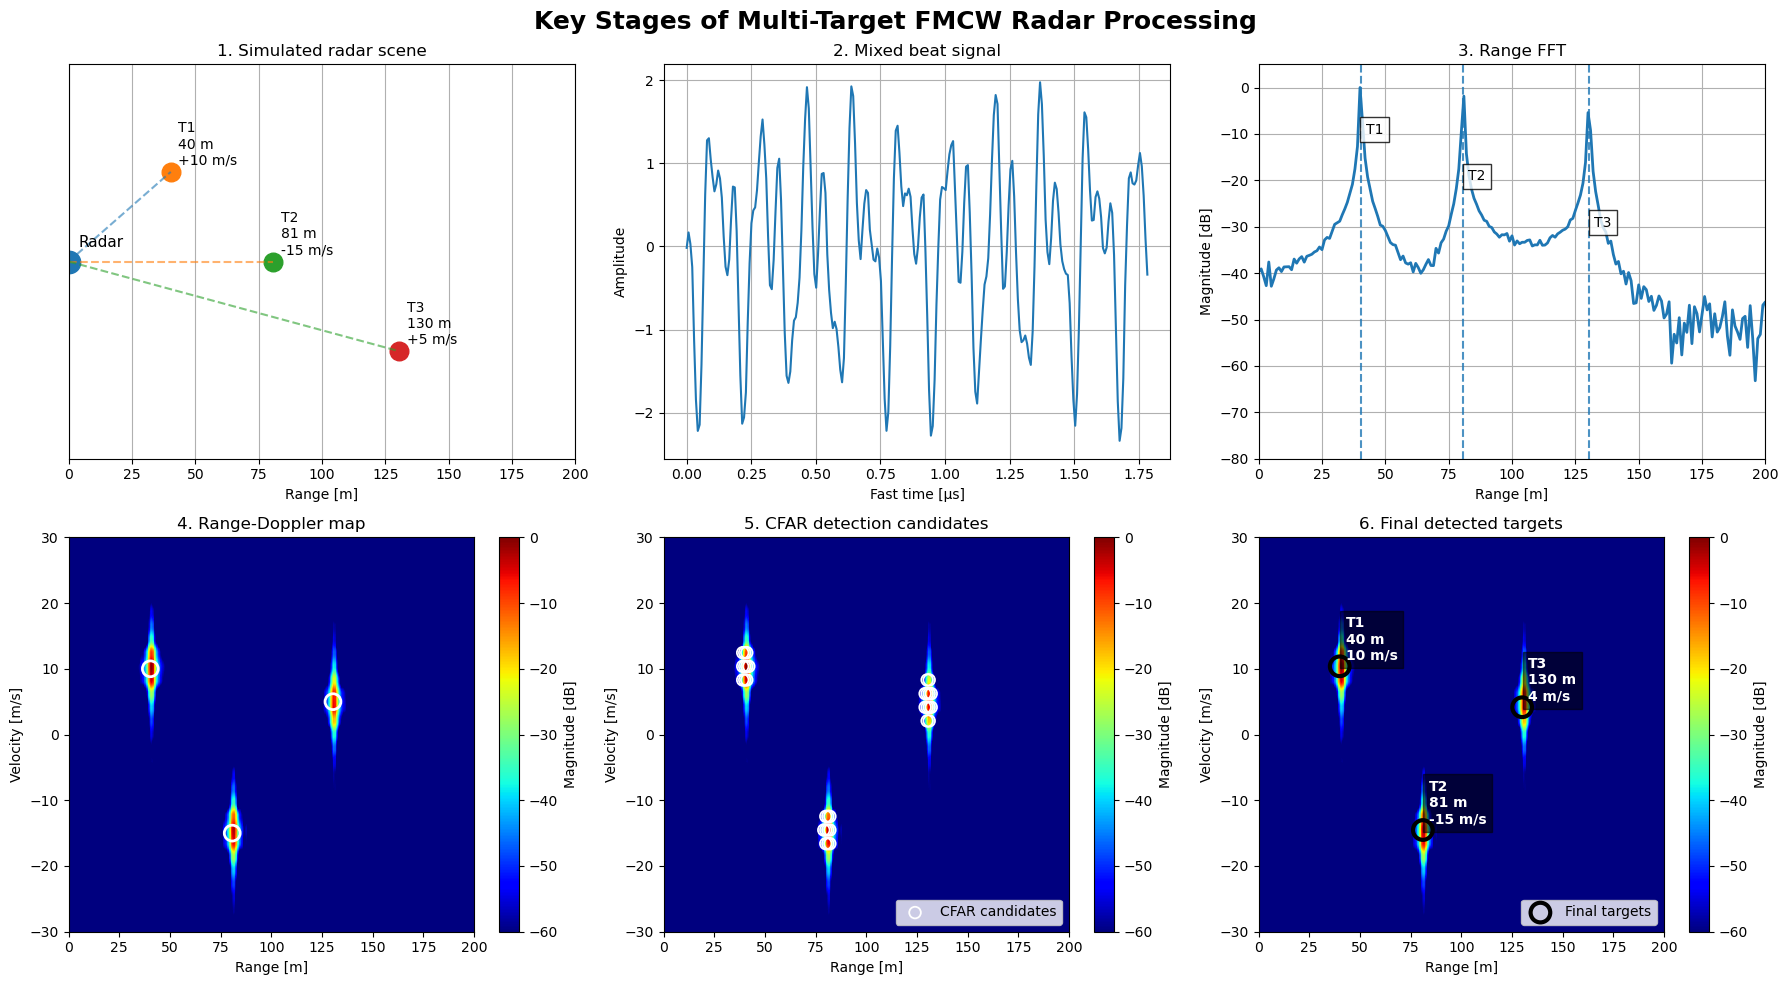

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Simple FMCW radar processing example
# Three moving targets are simulated and processed step by step.
# ------------------------------------------------------------

np.random.seed(2)

# ------------------------------------------------------------
# Radar parameters
# ------------------------------------------------------------

c = 3e8
fc = 77e9

max_range = 200
range_resolution = 1

B = c / (2 * range_resolution)
T_chirp = 5.5 * 2 * max_range / c
slope = B / T_chirp

Nr = 1024          # samples per chirp
Nd = 128           # number of chirps

t_fast = np.linspace(0, T_chirp, Nr, endpoint=False)
t_slow = np.arange(Nd) * T_chirp

# ------------------------------------------------------------
# Axes for plotting
# ------------------------------------------------------------

range_freq = np.fft.fftfreq(Nr, d=T_chirp / Nr)[:Nr // 2]
range_axis = range_freq * c / (2 * slope)

doppler_freq = np.fft.fftshift(np.fft.fftfreq(Nd, d=T_chirp))
velocity_axis = -doppler_freq * c / (2 * fc)

# ------------------------------------------------------------
# Target scene
# ------------------------------------------------------------

targets = [
    {"range": 40.3,  "velocity": 10,  "amplitude": 1.0},
    {"range": 80.7,  "velocity": -15, "amplitude": 0.8},
    {"range": 130.4, "velocity": 5,   "amplitude": 0.6},
]

# ------------------------------------------------------------
# Create the beat signal received by the radar
# ------------------------------------------------------------

beat_data = np.zeros((Nd, Nr), dtype=complex)

for target in targets:
    R = target["range"]
    v = target["velocity"]
    A = target["amplitude"]

    delay = 2 * R / c
    doppler_shift = -2 * fc * v / c

    for chirp_idx in range(Nd):
        phase = 2 * np.pi * (
            fc * delay
            + doppler_shift * t_slow[chirp_idx]
            + slope * delay * t_fast
        )

        beat_data[chirp_idx, :] += A * np.exp(1j * phase)

# Add a small amount of noise so the plots look more realistic
noise_level = 0.04
noise = noise_level * (
    np.random.randn(Nd, Nr) + 1j * np.random.randn(Nd, Nr)
)

beat_data = beat_data + noise

# One chirp for time-domain visualization
beat_signal = np.real(beat_data[0, :])

# ------------------------------------------------------------
# Range FFT
# ------------------------------------------------------------

range_fft = np.fft.fft(beat_data, axis=1)
range_fft = range_fft[:, :Nr // 2]

range_profile = np.abs(range_fft[0])
range_profile_db = 20 * np.log10(
    range_profile / np.max(range_profile) + 1e-12
)

range_profile_db = np.maximum(range_profile_db, -80)

# ------------------------------------------------------------
# Range-Doppler map
# ------------------------------------------------------------

# Windowing makes the Range-Doppler map cleaner
range_window = np.hanning(Nr)
doppler_window = np.hanning(Nd)

windowed_data = beat_data * range_window
windowed_data = (windowed_data.T * doppler_window).T

range_fft_windowed = np.fft.fft(windowed_data, axis=1)
range_fft_windowed = range_fft_windowed[:, :Nr // 2]

range_doppler = np.fft.fftshift(
    np.fft.fft(range_fft_windowed, axis=0),
    axes=0
)

range_doppler_db = 20 * np.log10(np.abs(range_doppler) + 1e-12)
range_doppler_db = range_doppler_db - np.max(range_doppler_db)
range_doppler_db = np.maximum(range_doppler_db, -80)

# ------------------------------------------------------------
# Simple 2D CA-CFAR
# ------------------------------------------------------------

def ca_cfar_2d(power_map, guard=2, training=10, scale=12):
    rows, cols = power_map.shape
    detections = np.zeros_like(power_map, dtype=bool)

    margin = guard + training

    for row in range(margin, rows - margin):
        for col in range(margin, cols - margin):

            full_window = power_map[
                row - margin:row + margin + 1,
                col - margin:col + margin + 1
            ]

            guard_window = power_map[
                row - guard:row + guard + 1,
                col - guard:col + guard + 1
            ]

            noise_sum = np.sum(full_window) - np.sum(guard_window)
            noise_cells = full_window.size - guard_window.size
            noise_level = noise_sum / noise_cells

            threshold = scale * noise_level

            if power_map[row, col] > threshold:
                detections[row, col] = True

    return detections


def keep_local_peaks(power_map, detections, window_size=7):
    rows, cols = power_map.shape
    peaks = np.zeros_like(detections)

    half = window_size // 2

    for row in range(half, rows - half):
        for col in range(half, cols - half):

            if detections[row, col]:
                local_area = power_map[
                    row - half:row + half + 1,
                    col - half:col + half + 1
                ]

                if power_map[row, col] == np.max(local_area):
                    peaks[row, col] = True

    return peaks


rdm_power = np.abs(range_doppler) ** 2

cfar_detections = ca_cfar_2d(
    rdm_power,
    guard=2,
    training=10,
    scale=12
)

# Remove very weak and very far detections
cfar_detections &= range_doppler_db > -25
cfar_detections[:, range_axis > 155] = False

final_detections = keep_local_peaks(
    rdm_power,
    cfar_detections,
    window_size=7
)

# ------------------------------------------------------------
# Final detected target values
# ------------------------------------------------------------

det_rows, det_cols = np.where(final_detections)

detected_targets = []

for row, col in zip(det_rows, det_cols):
    detected_targets.append({
        "range": range_axis[col],
        "velocity": velocity_axis[row],
        "magnitude_db": range_doppler_db[row, col]
    })

detected_targets = sorted(
    detected_targets,
    key=lambda x: x["magnitude_db"],
    reverse=True
)

print("Detected targets:")
for i, target in enumerate(detected_targets[:3], start=1):
    print(
        f"T{i}: Range = {target['range']:.1f} m, "
        f"Velocity = {target['velocity']:.1f} m/s"
    )

# ------------------------------------------------------------
# Plot key stages only
# ------------------------------------------------------------

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.ravel()

# ------------------------------------------------------------
# 1. Radar scene
# ------------------------------------------------------------

ax = axs[0]

ax.scatter(0, 0, s=260, label="Radar")
ax.text(4, 0.08, "Radar", fontsize=11)

y_positions = [0.5, 0.0, -0.5]

for idx, target in enumerate(targets):
    R = target["range"]
    v = target["velocity"]
    y = y_positions[idx]

    ax.scatter(R, y, s=180)
    ax.plot([0, R], [0, y], "--", alpha=0.6)

    ax.text(
        R + 3,
        y + 0.04,
        f"T{idx + 1}\n{R:.0f} m\n{v:+.0f} m/s",
        fontsize=10
    )

ax.set_title("1. Simulated radar scene")
ax.set_xlabel("Range [m]")
ax.set_xlim(0, max_range)
ax.set_ylim(-1.1, 1.1)
ax.set_yticks([])
ax.grid(True)

# ------------------------------------------------------------
# 2. Beat signal
# ------------------------------------------------------------

ax = axs[1]

zoom_samples = 250

ax.plot(
    t_fast[:zoom_samples] * 1e6,
    beat_signal[:zoom_samples],
    linewidth=1.5
)

ax.set_title("2. Mixed beat signal")
ax.set_xlabel("Fast time [µs]")
ax.set_ylabel("Amplitude")
ax.grid(True)

# ------------------------------------------------------------
# 3. Range FFT
# ------------------------------------------------------------

ax = axs[2]

ax.plot(range_axis, range_profile_db, linewidth=2)

for idx, target in enumerate(targets):
    ax.axvline(target["range"], linestyle="--", alpha=0.8)

    ax.text(
        target["range"] + 2,
        -10 - idx * 10,
        f"T{idx + 1}",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8)
    )

ax.set_title("3. Range FFT")
ax.set_xlabel("Range [m]")
ax.set_ylabel("Magnitude [dB]")
ax.set_xlim(0, max_range)
ax.set_ylim(-80, 5)
ax.grid(True)

# ------------------------------------------------------------
# 4. Range-Doppler map
# ------------------------------------------------------------

ax = axs[3]

im = ax.imshow(
    range_doppler_db,
    aspect="auto",
    extent=[
        range_axis[0],
        range_axis[-1],
        velocity_axis[0],
        velocity_axis[-1]
    ],
    origin="lower",
    cmap="jet",
    vmin=-60,
    vmax=0
)

for target in targets:
    ax.scatter(
        target["range"],
        target["velocity"],
        s=130,
        facecolors="none",
        edgecolors="white",
        linewidths=2
    )

ax.set_title("4. Range-Doppler map")
ax.set_xlabel("Range [m]")
ax.set_ylabel("Velocity [m/s]")
ax.set_xlim(0, max_range)
ax.set_ylim(-30, 30)

plt.colorbar(im, ax=ax, label="Magnitude [dB]")

# ------------------------------------------------------------
# 5. CFAR detections
# ------------------------------------------------------------

ax = axs[4]

im = ax.imshow(
    range_doppler_db,
    aspect="auto",
    extent=[
        range_axis[0],
        range_axis[-1],
        velocity_axis[0],
        velocity_axis[-1]
    ],
    origin="lower",
    cmap="jet",
    vmin=-60,
    vmax=0
)

cfar_rows, cfar_cols = np.where(cfar_detections)

ax.scatter(
    range_axis[cfar_cols],
    velocity_axis[cfar_rows],
    facecolors="none",
    edgecolors="white",
    s=70,
    linewidths=1.3,
    label="CFAR candidates"
)

ax.set_title("5. CFAR detection candidates")
ax.set_xlabel("Range [m]")
ax.set_ylabel("Velocity [m/s]")
ax.set_xlim(0, max_range)
ax.set_ylim(-30, 30)
ax.legend(loc="lower right")

plt.colorbar(im, ax=ax, label="Magnitude [dB]")

# ------------------------------------------------------------
# 6. Final detected targets
# ------------------------------------------------------------

ax = axs[5]

im = ax.imshow(
    range_doppler_db,
    aspect="auto",
    extent=[
        range_axis[0],
        range_axis[-1],
        velocity_axis[0],
        velocity_axis[-1]
    ],
    origin="lower",
    cmap="jet",
    vmin=-60,
    vmax=0
)

peak_rows, peak_cols = np.where(final_detections)

ax.scatter(
    range_axis[peak_cols],
    velocity_axis[peak_rows],
    facecolors="none",
    edgecolors="black",
    s=200,
    linewidths=3,
    label="Final targets"
)

for idx, target in enumerate(detected_targets[:3], start=1):
    ax.text(
        target["range"] + 3,
        target["velocity"] + 1,
        f"T{idx}\n{target['range']:.0f} m\n{target['velocity']:.0f} m/s",
        color="white",
        fontsize=10,
        weight="bold",
        bbox=dict(facecolor="black", alpha=0.55)
    )

ax.set_title("6. Final detected targets")
ax.set_xlabel("Range [m]")
ax.set_ylabel("Velocity [m/s]")
ax.set_xlim(0, max_range)
ax.set_ylim(-30, 30)
ax.legend(loc="lower right")

plt.colorbar(im, ax=ax, label="Magnitude [dB]")

# ------------------------------------------------------------
# Finish
# ------------------------------------------------------------

plt.suptitle(
    "Key Stages of Multi-Target FMCW Radar Processing",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()
plt.show()